# DREAMS Nodal Hosting Capacity
This demo notebook is designed to show to to perform nodal hosting 
capacity calculations using DREAMS.

Unlike the QSTS hosting capacity simulations, only a single snapshot in
time is examined, and the maximum value of an additional asset is 
calculated for each bus of interest independent of other asset additions.

Selecting buses to test, runing the simulation, anlyzing results, and
creating plots is demonstrated.

In [1]:
import dreams

import matplotlib.pyplot as plt

from pathlib import Path

# Loading Demo Feeder
The demo feeder is loaded and a voltage profile plot is made to ensure
the model loads correctly, and that there is some headroom for voltage
fulctuations.

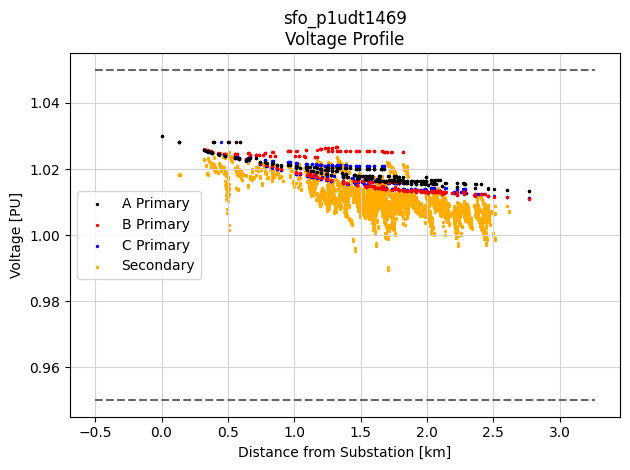

In [2]:
model_dir = Path(r'models') / r'sfo_p1udt1469'
feeder = dreams.Feeder(model_dir/'Main.dss', name='sfo_p1udt1469')
fig, ax = feeder.plot()

# Identification of Buses to Test
For this work, a sample of roughtly 10 busses will be selected as full 
nodal hosting capacity is a computationally heavy task.
Additionally, the buses nearest the voltage source are skipped to allow
more reasonable results.

In [3]:
# identify 3 phase primary buses
primary_buses = feeder.buses['primary']
three_phase = feeder.buses['n_phases'] == 3
mask = primary_buses & three_phase
buses_to_test = feeder.buses[mask].index.values

# thin down bus selection for speed of demo
slice_step = int(len(buses_to_test)/10)
primary_buses = buses_to_test[2::slice_step]  # start at 2 to avoid source test

In [4]:
# select secondary buses
secondary_bus_mask = ~feeder.buses['primary']
buses_to_test = feeder.buses[secondary_bus_mask].index.values

# thin down buses to test for speed
slice_step = int(len(buses_to_test)/10)
secondary_buses = buses_to_test[::slice_step]

# Load (Demand) Hosting Capacity
Load, or Demand, hosting capcity is effectively a measure of how much 
additional load or demand can be connected to a system location before 
violations occur.

The defaul action of the `NodalSnapshot` class is to perform demand 
voltage constrained hosting capaity on given bus names.
The  optional `constraint` parameter is set to `thermal` to calculate 
thermal constrainted hosting capacity.

For this example, primary (medium voltage) and secondary buses are 
separated as results from differnt voltage levels often differ by orders
of magnitude.

NOTE: Each code block of results may take over a minute to compute. 

In [5]:
voltage_hc = dreams.hc.NodalSnapshot(feeder, bus_names=primary_buses)
thermal_hc = dreams.hc.NodalSnapshot(feeder, bus_names=primary_buses, constraint='thermal')


Started voltage constrained hosting capacity
Bus 11/11  (100.00% complete in 21.66 seconds)  
Started thermal constrained hosting capacity
Bus 11/11  (100.00% complete in 21.08 seconds)  


In [6]:
sec_voltage_hc = dreams.hc.NodalSnapshot(feeder, bus_names=secondary_buses)
sec_thermal_hc = dreams.hc.NodalSnapshot(feeder, bus_names=secondary_buses, constraint='thermal')


Started voltage constrained hosting capacity
Bus 11/11  (100.00% complete in 22.05 seconds)  
Started thermal constrained hosting capacity
Bus 11/11  (100.00% complete in 18.84 seconds)  


# Generation (PV) Hosting Capacity
Similar to the load hosting capacity, the generation, or 'pv' hosting 
capacity finds the largest asset that can connect before system 
violations occur, however, instead of a load, a generation source is 
added.

Again, the `NodalSnapshot` class accepts the same parameters, but an 
additional `hc_kind` parameter is set to `pv`.

NOTE: Each code block may take a minute to execute.

In [7]:
pv_voltage_hc = dreams.hc.NodalSnapshot(feeder, bus_names=primary_buses, hc_kind='pv')
pv_thermal_hc = dreams.hc.NodalSnapshot(feeder, bus_names=primary_buses, hc_kind='pv', constraint='thermal')

Started voltage constrained hosting capacity
Bus 11/11  (100.00% complete in 20.27 seconds)  
Started thermal constrained hosting capacity
Bus 11/11  (100.00% complete in 20.84 seconds)  


In [8]:
pv_sec_voltage_hc = dreams.hc.NodalSnapshot(feeder, bus_names=secondary_buses, hc_kind='pv')
pv_sec_thermal_hc = dreams.hc.NodalSnapshot(feeder, bus_names=secondary_buses, hc_kind='pv', constraint='thermal')

Started voltage constrained hosting capacity
Bus 11/11  (100.00% complete in 21.05 seconds)  
Started thermal constrained hosting capacity
Bus 11/11  (100.00% complete in 21.28 seconds)  


# Results
The returned object of `NodalSnapshot` includes the DataFrame `result_df`
that contains results for each bus tested. This can be exported or
analyzed via normal pandas approaches.

In [9]:
voltage_hc.result_df.head()

,voltage_hc_kw,iterations,over_voltage,under_voltage,line_overload,xfmr_overload,n_violation_types,bus_dist_km
p1udt940,63171,19,False,True,True,False,2,0.318832
p1udt171-p1udt177xx,23405,18,False,True,True,False,2,0.871147
p1udt172-p1udt233x,15224,18,False,True,True,False,2,1.452682
p1udt338-p1udt420x,14357,18,False,True,True,False,2,1.368017
p1udt372-p1udt373xx,12887,18,False,True,True,False,2,1.849604


In [10]:
voltage_hc.result_df['voltage_hc_kw'].describe()

count       11.000000
mean     24247.454545
std      18481.343308
min      11034.000000
25%      12778.000000
50%      15224.000000
75%      24866.500000
max      63171.000000
Name: voltage_hc_kw, dtype: float64

The class also includes a `plot` method that shows hosting capacity on
the y-axis and distances from substation on the x-axis.

<Axes: title={'center': 'Voltage Hosting Capacity\nLOAD '}, xlabel='Distance from Substation [km]', ylabel='Hosting Capacity [kW]'>

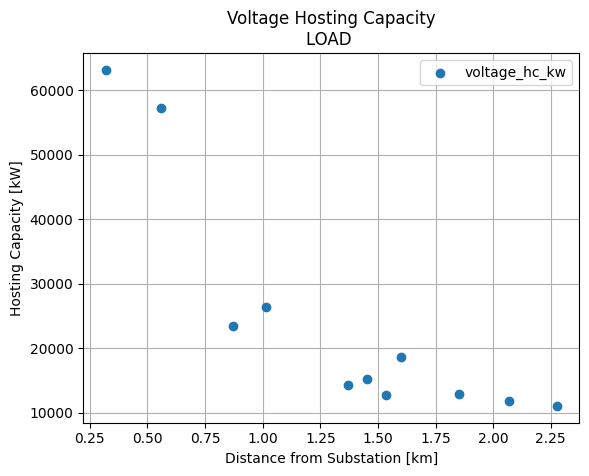

In [11]:
voltage_hc.plot()

A `kind` parameter can be set to `violation` to plot the same information
with points colored by violation type, and an optional `y_min` to
modify the lowest y valu ploted.

<Axes: xlabel='Distance from Substation [km]', ylabel='Hosting Capacity [kw]'>

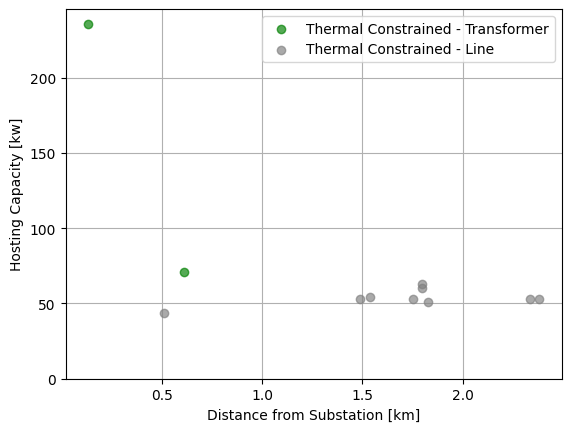

In [12]:
pv_sec_thermal_hc.plot(kind='violation', y_min=0)

Since the `plot` method returns a matplotlib axis object, these can be 
combined to create more informative plots.
As shown below, the load hosting capacity for both constraints and 
voltage levels are combined in a single plot.

Text(0.5, 0.98, 'Load Hosting Capacity')

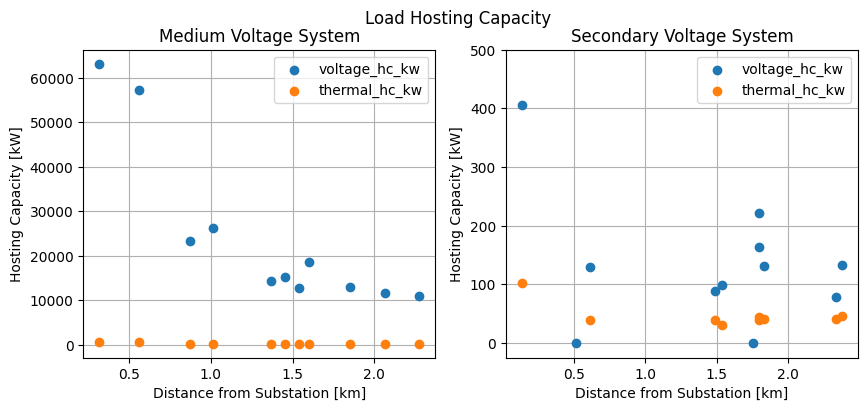

In [13]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

voltage_hc.plot(ax=axes[0])
thermal_hc.plot(ax=axes[0])
axes[0].set_title('Medium Voltage System')

sec_voltage_hc.plot(ax=axes[1])
sec_thermal_hc.plot(ax=axes[1])
axes[1].set_ylim([-25,500])  # to remove outliers
axes[1].set_title('Secondary Voltage System')
fig.suptitle('Load Hosting Capacity')

A similar combination approach can be used with the violation parameter.

This allows the various types to be more easily compared.
As shown, below, added demand has more under voltage issues, and added
generation has more over voltage issues. This is typical.
The very large voltage hosting capacity results may be unrealistic, 
possibly due to model simplifications or assumptions, like the abscense
of a substation transformer or certain settings of the voltage source.

Text(0.5, 0.98, 'Load Hosting Capacity')

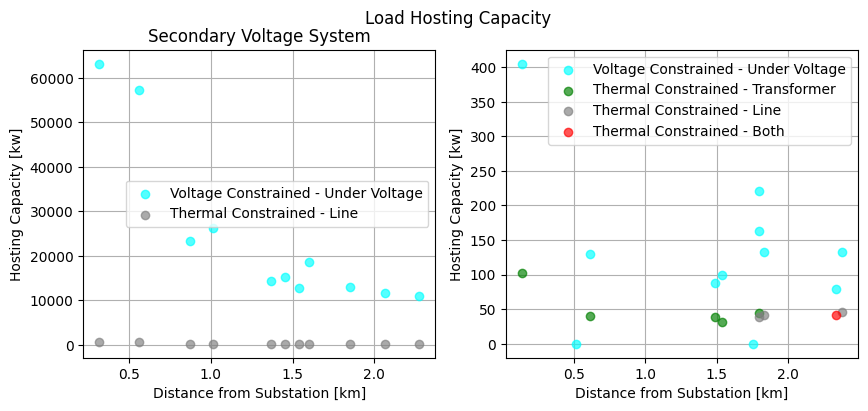

In [14]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

voltage_hc.plot(kind='violation', ax=axes[0])
thermal_hc.plot(kind='violation', ax=axes[0])
axes[0].set_title('Medium Voltage System')

sec_voltage_hc.plot(kind='violation', ax=axes[1])
sec_thermal_hc.plot(kind='violation', ax=axes[1])
axes[0].set_title('Secondary Voltage System')

fig.suptitle('Load Hosting Capacity')

Text(0.5, 0.98, 'PV Hosting Capacity')

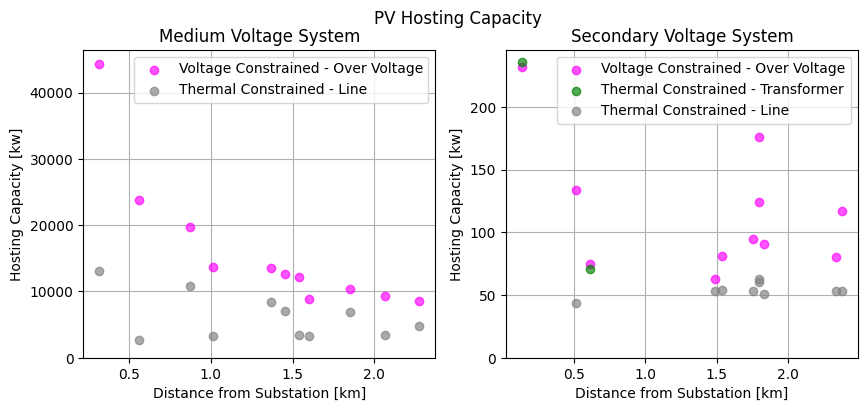

In [15]:

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

pv_voltage_hc.plot(kind='violation', ax=axes[0])
pv_thermal_hc.plot(kind='violation', ax=axes[0], y_min=0)
axes[0].set_title('Medium Voltage System')

pv_sec_voltage_hc.plot(kind='violation', ax=axes[1])
pv_sec_thermal_hc.plot(kind='violation', ax=axes[1], y_min=0)
axes[1].set_title('Secondary Voltage System')
fig.suptitle('PV Hosting Capacity')


This concluces the nodal hosting capacity demo showing how to:
* load a feeder
* select buses for hosting capacity testing
* run thermal and voltage constrained demand and generation hosting capacity simulations
* analyze results
* make simple and combined result plots
